In [1]:
import os
import pickle
import collections
import random
import copy
from typing import Tuple

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn.functional as F


In [11]:
class ReplayBuffer():
    def __init__(self,capacity:int,device:torch.device = torch.device("cpu")) -> None:
        self.device = device
        self.buffer = collections.deque(maxlen=capacity)
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
        
    def sample(self,batch_size:int) -> Tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
        mini_batch = random.sample(self.buffer,batch_size)
        obs_batch, action_batch, reward_batch, next_obs_batch, done_batch = zip(*mini_batch)
        
        obs_batch = torch.tensor(np.array(obs_batch),dtype=torch.float32,device=self.device)
        
        action_batch = torch.tensor(np.array(action_batch),dtype=torch.float32,device=self.device) 

        
        reward_batch = torch.tensor(np.array(reward_batch),dtype=torch.float32,device=self.device).unsqueeze(-1)
        next_obs_batch = torch.tensor(np.array(next_obs_batch),dtype=torch.float32,device=self.device)
        done_batch = torch.tensor(np.array(done_batch),dtype=torch.float32,device=self.device).unsqueeze(-1)
          
        return obs_batch, action_batch, reward_batch, next_obs_batch, done_batch
    
    def __len__(self) -> int:
        return len(self.buffer)
    
    def save_to_disk(self, filename:str) -> None:
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        with open(filename, 'wb') as f:
            pickle.dump(self.buffer, f)
    
    def load_from_disk(self, filename:str) -> None:
        with open(filename, 'rb') as f:
            self.buffer = pickle.load(f)
            
            
class DDPG_Agent():
    
    def __init__(self,
                 replay_buffer:ReplayBuffer,
                 replay_start_size:int,
                 batch_size:int,
                 actor_update_frequent:int, # The frequency of updating the actor network
                 target_update_tau:float, # The parameter for soft update
                 actor_network:torch.nn.Module, 
                 critic_network:torch.nn.Module,
                 actor_optimizer:torch.optim.Optimizer,
                 critic_optimizer:torch.optim.Optimizer,
                 gamma:float = 0.9,
                 sigma_noise:float = 0.2,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        
        self.device = device
        self.exp_counter = 0
        
        self.replay_buffer = replay_buffer
        self.replay_start_size = replay_start_size
        self.batch_size = batch_size
        
        self.actor_update_frequent = actor_update_frequent
        self.target_update_tau = target_update_tau
        
        self.main_critic_network = critic_network.to(self.device)
        self.target_critic_network = copy.deepcopy(critic_network).to(self.device)
        self.main_actor_network = actor_network.to(self.device)
        self.target_actor_network = copy.deepcopy(actor_network).to(self.device)
        
        self.critic_optimizer = critic_optimizer
        self.actor_optimizer = actor_optimizer
        
        self.gamma = gamma
        self.sigma_noise = sigma_noise
        
    def get_behavior_action(self,obs:np.ndarray) -> np.ndarray:        
        obs = torch.tensor(obs,dtype=torch.float32).to(self.device)
        action = self.main_actor_network(obs)
        action += torch.normal(0, torch.tensor(self.sigma_noise,dtype=torch.float32,device=self.device))
        action = action.cpu().detach().numpy()
        
        return action
    
    def update_target_networks(self) -> None:     
        def soft_update_network(self,main_network:torch.nn,target_network:torch.nn) -> None:
            """Soft update the parameters of the target network"""
            for target_param, main_param in zip(target_network.parameters(), main_network.parameters()):
                target_param.data.copy_(self.target_update_tau * main_param.data + (1.0 - self.target_update_tau) * target_param.data)
                
        soft_update_network(self,self.main_actor_network,self.target_actor_network)
        soft_update_network(self,self.main_critic_network,self.target_critic_network)
        
    def batch_Q_approximation(self,
                              obs:torch.Tensor,
                              action:torch.Tensor,
                              reward:torch.Tensor,
                              next_obs:torch.Tensor,
                              done:torch.Tensor) -> None:
        """To update the main critic network"""
        current_Q = self.main_critic_network(obs,action)
        TD_target = reward + (1-done) * self.gamma * self.target_critic_network(next_obs,self.target_actor_network(next_obs))
        critic_loss = torch.mean(F.mse_loss(current_Q,TD_target.detach())) # detach the TD_target for frozen the parameters of the target network
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        
    def batch_actor_update(self,obs:torch.Tensor) -> None:
        
        """To update the main actor network. 
            However, before that, we need to freeze the parameters of the main critic network"""
        for p in self.main_critic_network.parameters():
            p.requires_grad = False
        
        actor_loss = torch.mean(-self.main_critic_network(obs,self.main_actor_network(obs)))       
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        """After updating the main actor network, 
            we need to unfreeze the parameters of the main critic network"""
        for p in self.main_critic_network.parameters():
            p.requires_grad = True
    
    def Q_approximation(self,
                    obs:np.ndarray,
                    action:float,
                    reward:float,
                    next_obs:np.ndarray,
                    done:bool) -> None:
        
        """Here, we continue use the framework of DQN, since DDPG is an extension of DQN.
            The max Q value is approximated by the target network."""
        
        self.exp_counter += 1
        self.replay_buffer.append((obs,action,reward,next_obs,done))

        if len(self.replay_buffer) > self.replay_start_size:
            obs,action,reward,next_obs,done = self.replay_buffer.sample(self.batch_size)
            self.batch_Q_approximation(obs,action,reward,next_obs,done) # train critic 
            if self.exp_counter%self.actor_update_frequent == 0: # update actor network every actor_update_frequent steps
                self.batch_actor_update(obs) # train actor
                self.update_target_networks()# soft update target networks                  

In [3]:
class Actor_Network(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(Actor_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        
        return x
    

class Critic_Network(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(Critic_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim + action_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,1)
            
    def forward(self,obs:torch.Tensor,action:torch.Tensor) -> torch.Tensor:
        x = torch.cat([obs,action],dim=-1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
                
        return x 

In [5]:

class TrainManager():
    
    def __init__(self,
                 env:gym.Env,
                 episode_num:int = 1000,
                 eval_iters:int = 10,
                 actor_lr:float = 1e-3,
                 critic_lr:float = 1e-3,
                 gamma:float = 0.95,
                 sigma_noise:float = 0.2,
                 buffer_capacity:int = 2000,
                 replay_start_size:int = 200,
                 actor_update_frequent:int = 2,
                 target_update_tau:float = 1e-3,
                 batch_size:int = 32,
                 seed:int = 0,
                 device:torch.device = torch.device("cpu"),
                 ) -> None:
        
        self.seed = seed
        random.seed(self.seed)
        torch.manual_seed(self.seed)
        torch.cuda.manual_seed_all(self.seed)
        np.random.seed(self.seed)
        torch.backends.cudnn.deterministic = True
        
        self.device = torch.device(device)
        
        self.train_env = env
        self.eval_env = copy.deepcopy(env)
        _ = self.train_env.reset(seed=self.seed)
        _ = self.eval_env.reset(seed=self.seed+1)
        self.episode_num = episode_num
        obs_dim = gym.spaces.utils.flatdim(env.observation_space)
        action_dim = gym.spaces.utils.flatdim(env.action_space)
                
        self.buffer = ReplayBuffer(capacity=buffer_capacity,device=self.device)

        
        actor_network = Actor_Network(obs_dim,action_dim).to(self.device)
        actor_optimizer = torch.optim.Adam(actor_network.parameters(),lr=actor_lr)
        critic_network = Critic_Network(obs_dim,action_dim).to(self.device)
        critic_optimizer = torch.optim.Adam(critic_network.parameters(),lr=critic_lr)
        self.agent = DDPG_Agent(replay_buffer = self.buffer,
                                replay_start_size = replay_start_size,
                                batch_size = batch_size,
                                actor_update_frequent = actor_update_frequent, 
                                target_update_tau = target_update_tau,
                                actor_network = actor_network,
                                critic_network = critic_network,
                                actor_optimizer = actor_optimizer,
                                critic_optimizer = critic_optimizer,
                                gamma = gamma,
                                sigma_noise = sigma_noise,
                                device = self.device
                                )        
        self.eval_iters = eval_iters
        self.eval_rewards = [] 
        
    def train_episode(self) -> None:
        obs,_ = self.train_env.reset()
        done = False 
        while not done:
            action = self.agent.get_behavior_action(obs) 
            next_obs, reward, terminated, truncated, _ = self.train_env.step(action)
            done = terminated or truncated
            """Here, we continue use the framework of DQN, since DDPG is an extension of DQN.
            The max Q value is approximated by the target network.""" 
            self.agent.Q_approximation(obs,action,reward,next_obs,done)               
            obs = next_obs
  
    def train(self) -> None:
        self.exp_counter = 0
        with tqdm(total=self.episode_num, desc='Training') as pbar:        
            for _ in range(self.episode_num):
                _ = self.train_episode()
                avg_reward = self.eval()
                pbar.set_postfix({"Avg. Test Reward": (avg_reward)})
                pbar.update(1)
        
    def eval(self) -> float:
        temp_eval_rewards = []
        for _ in range(self.eval_iters):
            obs,_ = self.eval_env.reset()
            episode_reward = 0
            done = False
            while not done:
                action = self.agent.get_behavior_action(obs)
                next_obs, reward, terminated, truncated, _ = self.eval_env.step(action)
                done = terminated or truncated
                episode_reward += reward
                obs = next_obs
                pass
            temp_eval_rewards.append(episode_reward)
            pass
        self.eval_rewards.append(temp_eval_rewards)
        
        return np.mean(temp_eval_rewards)                       

In [6]:
class NormalizedActions(gym.ActionWrapper):
    '''
    Add this wrapper to normalize the action space. So the algorithm code can be general.
    '''
    def __init__(self, env: gym.Env):
        super().__init__(env)
    
    def action(self, action: np.ndarray) -> np.ndarray:
        # Force in range and clip
        low_bound = self.action_space.low
        upper_bound = self.action_space.high
        scale = (upper_bound - low_bound) * 0.5
        bias = (upper_bound + low_bound) * 0.5
        action = scale * action + bias
        action = np.clip(action, low_bound, upper_bound)
        return action

In [7]:
train_env = NormalizedActions(gym.make('Pendulum-v1'))
Manager = TrainManager(env = train_env,
                    episode_num = 500,
                    eval_iters = 10,
                    actor_lr = 1e-3,
                    critic_lr = 1e-2,
                    gamma = 0.95,
                    sigma_noise = 0.01,
                    buffer_capacity = 10000,
                    replay_start_size = 1000,
                    actor_update_frequent = 1,
                    target_update_tau = 5e-3,
                    batch_size = 64,
                    seed = 0,
                    device = "cpu"
                    )
Manager.train()

Training: 100%|██████████| 500/500 [08:34<00:00,  1.03s/it, Avg. Test Reward=-129]   


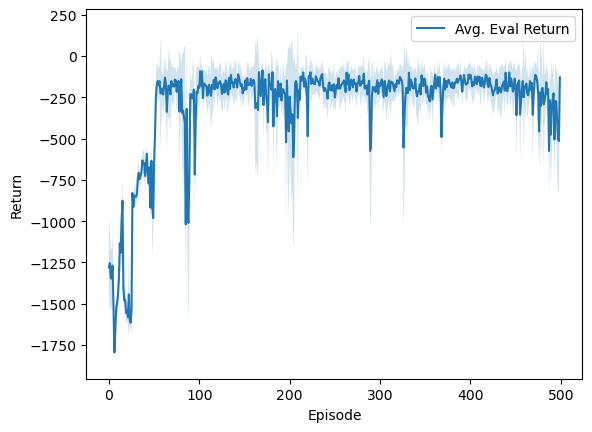

In [8]:
'''Plotting eval results'''
Manager.eval_rewards = np.array(Manager.eval_rewards)
means = np.mean(Manager.eval_rewards,axis=-1)
stds = np.std(Manager.eval_rewards,axis=-1)
plt.plot(means,label="Avg. Eval Return")
plt.fill_between(np.arange(len(means)),means-stds,means+stds,alpha=0.2)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()

In [9]:
'''Saving policy network for offline RL'''
actor_saving_path = "../Models/Pendulum500_DDPG_Actor.pth"
os.makedirs(os.path.dirname(actor_saving_path), exist_ok=True)
torch.save(Manager.agent.main_actor_network.state_dict(), actor_saving_path)